In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
import ipywidgets as widgets
from IPython.display import display, clear_output

Размер изображения: (1152, 864)


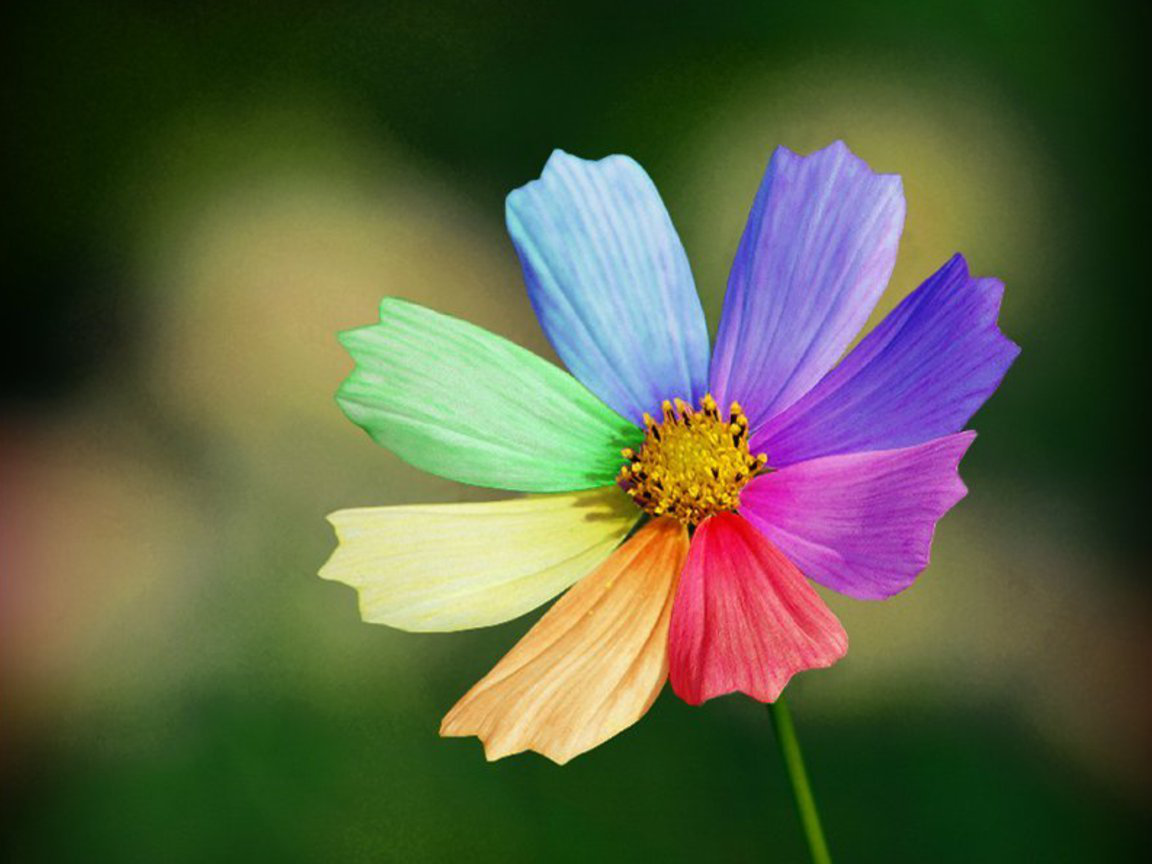

In [2]:
IMAGE_PATH = "image.jpg"

image = Image.open(IMAGE_PATH).convert("RGB")
rgb = np.asarray(image, dtype=np.float32) / 255.0

hsv_original = rgb_to_hsv(rgb)

print("Размер изображения:", image.size)
display(image)

In [3]:
hue_slider = widgets.IntSlider(
    value=0,
    min=-180,
    max=180,
    step=1,
    description="Оттенок:",
    continuous_update=True
)

saturation_slider = widgets.IntSlider(
    value=100,
    min=0,
    max=200,
    step=1,
    description="Насыщ.:",
    continuous_update=True
)

value_slider = widgets.IntSlider(
    value=100,
    min=0,
    max=200,
    step=1,
    description="Яркость:",
    continuous_update=True
)

output = widgets.Output()

current_rgb = rgb.copy()


def apply_hsv_changes(hue, saturation, value):
    global current_rgb

    hsv = hsv_original.copy()

    hsv[..., 0] = (hsv[..., 0] + hue / 360.0) % 1.0

    hsv[..., 1] = np.clip(hsv[..., 1] * saturation / 100.0, 0.0, 1.0)
    hsv[..., 2] = np.clip(hsv[..., 2] * value / 100.0, 0.0, 1.0)

    current_rgb = hsv_to_rgb(hsv)

    with output:
        clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(rgb)
        axes[0].set_title("Исходное изображение")
        axes[0].axis("off")

        axes[1].imshow(current_rgb)
        axes[1].set_title(
            f"Результат: H={hue}°, S={saturation}%, V={value}%"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


controls = widgets.VBox([
    hue_slider,
    saturation_slider,
    value_slider
])

interactive = widgets.interactive_output(
    apply_hsv_changes,
    {
        "hue": hue_slider,
        "saturation": saturation_slider,
        "value": value_slider
    }
)

display(controls, output)
apply_hsv_changes(
    hue_slider.value,
    saturation_slider.value,
    value_slider.value
)

Output()

In [4]:
save_button = widgets.Button(
    description="Сохранить результат",
    button_style="success"
)

save_output = widgets.Output()


def save_image(_):
    rgb_uint8 = (np.clip(current_rgb, 0.0, 1.0) * 255).astype(np.uint8)
    result_image = Image.fromarray(rgb_uint8, mode="RGB")

    output_path = "result.png"
    result_image.save(output_path)

    with save_output:
        clear_output(wait=True)
        print(f"Изображение сохранено в файл: {output_path}")


save_button.on_click(save_image)

display(save_button, save_output)

Button(button_style='success', description='Сохранить результат', style=ButtonStyle())

Output()